#Introdução

## Projeto Final - Introdução à Ciência de Dados

## Aluna(o): Joana Dias e Cristiano A. Barbosa
## Professor: Alexandre Roriz
## Disciplina: Introdução à Ciência de Dados


# Análise de Saúde Mental em Adolescentes e Uso de Redes Sociais

Este estudo tem como objetivo analisar a relação entre o uso de redes sociais e indicadores de saúde mental em adolescentes. Serão investigados fatores como ansiedade, estresse, depressão, sono, interação social, atividade física e desempenho acadêmico.

A análise busca identificar padrões e possíveis associações entre o comportamento digital dos estudantes e aspectos relacionados ao seu bem-estar emocional e acadêmico.


##Entendimento dos Dados

##Carregamento
###limpeza, tradução e preparação

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

url = 'https://raw.githubusercontent.com/Alvenato/Introducao-a-Ciencia-de-Dados/main/Teen_Mental_Health_Dataset_Cleaned.csv'

mh = pd.read_csv(url)

mh= mh.rename(columns={
    "student_id": "Id_estudante",
    "age":"Idade",
    "gender":"Gênero",
    "daily_social_media_hours":"Tempo_gasto_redes",
    "platform_usage":"Plataforma_usada",
    "sleep_hours":"Horas_dormidas",
    "screen_time_before_sleep":"Tempo_tela_antes_dormir",
    "academic_performance":"Performance_academica",
    "physical_activity":"Atividade_fisica",
    "social_interaction_level":"Nível_interação_social",
    "social_media_usage":"Uso_redes_sociais",
    "stress_level":"Nivel_estress",
    "anxiety_level":"Nivel_ansiedade",
    "addiction_level":"Nivel_dependência",
    "depression_label":"Depressão"
})

#Nesta etapa, é realizada a importação da biblioteca Pandas, utilizada para manipulação e análise de dados em Python.
#Em seguida, o conjunto de dados Teen Mental Health (Saúde Mental de Adolescentes) é carregado diretamente de um repositório público do GitHub por meio de uma URL.
#Após o carregamento, os nomes das colunas são renomeados para o idioma português utilizando o método rename().
#Essa padronização tem como objetivo facilitar a compreensão dos atributos durante a análise exploratória e a construção de visualizações, tornando os dados mais acessíveis para usuários que utilizam o português como idioma principal.
#As variáveis contemplam informações relacionadas ao perfil dos estudantes, hábitos de uso de redes sociais, sono, desempenho acadêmico, atividade física, interação social e indicadores de saúde mental, como níveis de estresse, ansiedade, dependência e depressão.
#Objetivo da etapa: preparar e padronizar os dados para as próximas fases da análise, garantindo maior clareza e facilidade na interpretação das informações.

In [3]:
mh.head(21)
#Nessa célula, selecionamos e exibimos as 20 primeiras linhas da nossa base de dados.
#Esse procedimento foi realizado com o objetivo de visualizar a estrutura inicial do conjunto de dados, verificar os nomes das variáveis, os tipos de informações
#presentes e identificar possíveis inconsistências ou valores inesperados antes do início das análises.
#Essa etapa é importante no processo de exploração dos dados, pois permite uma compreensão geral da base e auxilia nas decisões sobre os
#tratamentos e análises que serão realizados posteriormente.

,Id_estudante,Idade,Gênero,Tempo_gasto_redes,Plataforma_usada,Horas_dormidas,Tempo_tela_antes_dormir,Performance_academica,Atividade_fisica,Nível_interação_social,Nivel_estress,Nivel_ansiedade,Nivel_dependência,Depressão
0,1001,14,male,7.9,Instagram,7.4,2.9,3.01,1.5,low,2,2,1,0
1,1002,19,female,1.9,TikTok,8.0,2.9,3.22,0.8,high,8,1,10,0
2,1003,17,female,1.3,Instagram,7.6,0.5,3.92,0.0,high,2,4,2,0
3,1004,15,male,7.4,TikTok,6.9,1.6,3.48,0.8,medium,1,7,9,0
4,1005,15,female,4.7,Both,4.9,3.0,2.37,1.4,medium,3,5,2,0
5,1006,19,female,7.4,Both,4.4,2.4,2.63,0.6,high,3,5,7,0
6,1007,18,female,2.5,Instagram,6.4,2.4,2.63,0.7,low,2,2,5,0
7,1008,16,male,4.0,Both,4.2,0.5,2.40,1.3,low,6,10,5,0
8,1009,19,female,3.3,TikTok,5.0,2.1,2.04,0.9,high,1,10,9,0
9,1010,15,male,1.9,TikTok,4.9,1.5,3.77,1.1,high,1,1,4,0


###Tradução

In [ ]:
mh["Gênero"] = mh["Gênero"].replace({
    "male": "Masculino",
    "female": "Feminino"
})
mh["Nível_interação_social"] = mh["Nível_interação_social"].replace({
    "low": "Baixo",
    "medium": "Médio",
    "high": "Alto"
})
mh["Plataforma_usada"] = mh["Plataforma_usada"].replace({
    "Instagram":"Instagram",
    "TikTok":"TikTok",
    "Both":"Ambas"
})


#Foi realizada a tradução e padronização das variáveis categóricas do conjunto de dados, convertendo os valores originalmente em inglês para português.
#Essa etapa contribui para uma melhor compreensão dos dados e para a apresentação dos resultados de forma mais clara e consistente.

## Contagem de Gênero

In [6]:
mh["Gênero"].value_counts()

#Nessa célula, utilizamos o comando value_counts() para contabilizar a quantidade de estudantes em cada categoria da variável Gênero.
#Essa verificação nos ajudou a entender como a amostra está distribuída entre participantes do sexo masculino e feminino,
#fornecendo uma visão geral da composição da base de dados.

,count
Gênero,
male,615
female,585


Os resultados indicaram uma distribuição equilibrada entre os gêneros, com a mesma quantidade de participantes do sexo masculino e feminino, contribuindo para análises comparativas mais representativas entre esses grupos.

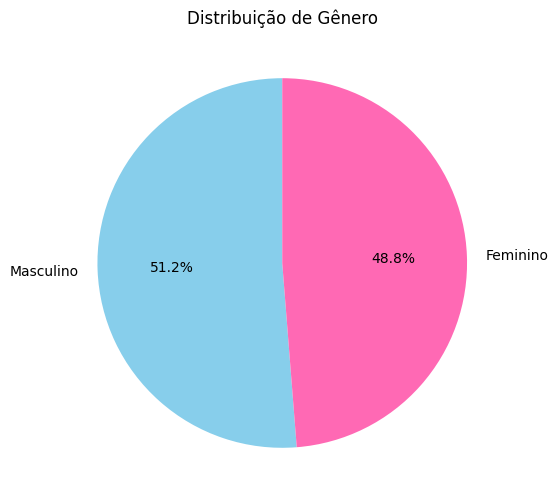

In [ ]:
Gênero = mh["Gênero"].value_counts()

cores = ["#87CEEB", "#FF69B4"]  # Azul céu, Rosa

# Gráfico de pizza
plt.figure(figsize=(8, 6))
plt.pie(
    Gênero,
    labels=Gênero.index,
    autopct='%1.1f%%', #Porcentagem dentro do grafico
    startangle=90,
    colors=cores
)

plt.title("Distribuição de Gênero")

plt.show()



#Nessa célula, inicialmente realizamos a contagem da quantidade de participantes em cada categoria da variável Gênero
#armazenando o resultado na variável Gênero. Em seguida, definimos uma paleta de cores para representar visualmente cada grupo e construímos um gráfico de pizza
#com o objetivo de ilustrar a proporção de estudantes do sexo masculino e feminino presentes na base de dados.
#Além disso, utilizamos o parâmetro autopct para exibir a porcentagem correspondente a cada categoria diretamente no gráfico,
#facilitando a interpretação dos resultados. Essa visualização permite compreender rapidamente a composição da amostra e verificar
#se há equilíbrio entre os grupos analisados.

## Contagem de cada idade

In [5]:
mh["Idade"].value_counts().sort_index()

#Nessa célula, contabilizamos a quantidade de estudantes em cada idade presente na base de dados. O método value_counts() foi utilizado para calcular
#a frequência de ocorrência de cada idade, enquanto sort_index() organizou os resultados em ordem crescente.
#Essa análise contribui para a caracterização do perfil dos participantes e fornece uma visão geral da distribuição das idades na amostra estudada.

,count
Idade,
13,200
14,153
15,180
16,163
17,170
18,172
19,162


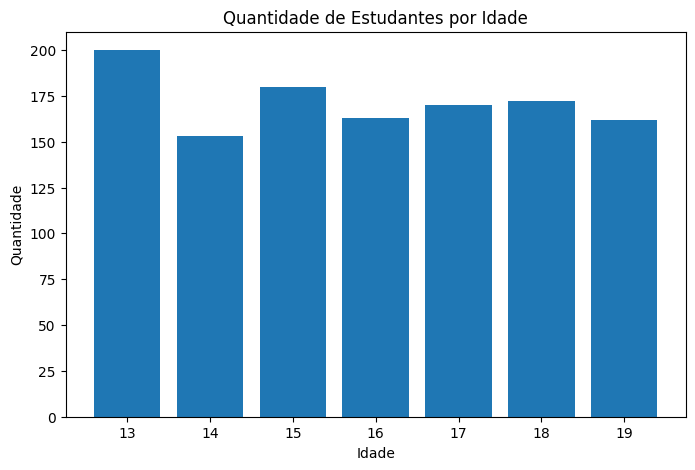

In [ ]:
idades = mh["Idade"].value_counts().sort_index()

plt.figure(figsize=(8, 5))
plt.bar(idades.index, idades.values)

plt.title("Quantidade de Estudantes por Idade")
plt.xlabel("Idade")
plt.ylabel("Quantidade")

plt.show()


#Nessa célula, construímos um gráfico de barras para representar a quantidade de estudantes em cada faixa etária presente na base de dados.
#Inicialmente, utilizamos os métodos value_counts() e sort_index() para calcular a frequência de cada idade e organizar os resultados em ordem crescente.
#Em seguida, empregamos a função plt.bar() para criar a visualização em barras, permitindo comparar de forma clara a distribuição dos participantes por idade.
#Essa análise auxilia na compreensão do perfil etário da amostra e na identificação de possíveis concentrações ou diferenças na representatividade das idades estudadas.

##Plataforma mais usada

In [ ]:

mh["Plataforma_usada"].value_counts()
#Nessa célula, utilizamos o comando value_counts() para contabilizar quantos estudantes utilizam cada uma das plataformas presentes na variável Plataforma_usada.
#Essa análise permitiu identificar quais redes sociais possuem maior adesão entre os participantes,
#auxiliando na compreensão dos hábitos de consumo digital da amostra estudada.

,count
Plataforma_usada,
Instagram,411
TikTok,398
Ambas,391


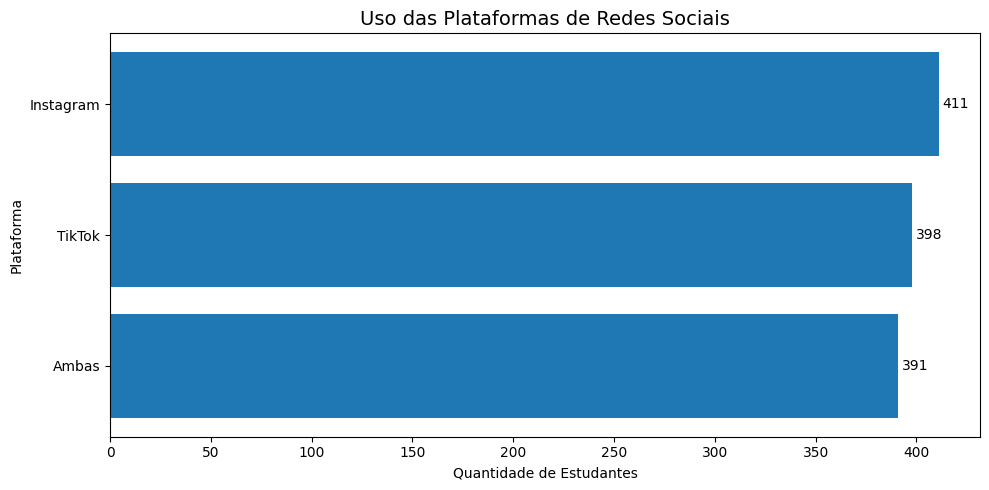

In [ ]:
plataformas = mh["Plataforma_usada"].value_counts()

plt.figure(figsize=(10, 5))
plt.barh(plataformas.index, plataformas.values)

plt.title("Uso das Plataformas de Redes Sociais", fontsize=14)
plt.xlabel("Quantidade de Estudantes")
plt.ylabel("Plataforma")

plt.gca().invert_yaxis()

for i, valor in enumerate(plataformas.values):
    plt.text(valor + 2, i, str(valor), va='center')

plt.tight_layout()
plt.show()

#Aqui, elaboramos um gráfico de barras horizontais para visualizar a frequência de uso das diferentes plataformas de redes sociais.
#Inicialmente, utilizamos o método value_counts() para contabilizar a quantidade de usuários em cada plataforma.
#Em seguida, aplicamos a função plt.barh() para representar essas informações graficamente, facilitando a comparação entre as categorias.
#Além disso, adicionamos rótulos com os valores absolutos em cada barra, tornando a interpretação dos resultados mais clara e objetiva.
#Essa análise possibilita identificar quais plataformas são mais utilizadas pelos participantes e compreender melhor seus hábitos digitais.

##Tempo médio gasto em redes sociais

In [ ]:

print(f"Média de horas por dia: {mh['Tempo_gasto_redes'].mean():.2f} horas")

#Nessa célula, calculamos o tempo médio diário que os estudantes dedicam às redes sociais.
#Para isso, utilizamos o método mean(), responsável por obter a média aritmética dos valores presentes na coluna.
#Em seguida, empregamos uma f-string para exibir o resultado de forma organizada e com duas casas decimais.
#Essa análise permite identificar, de maneira geral, quanto tempo os participantes permanecem conectados às redes sociais ao longo do dia,
#fornecendo um importante indicador para as investigações sobre os hábitos digitais e sua possível relação com aspectos da saúde mental.

Média de horas por dia: 4.54 horas


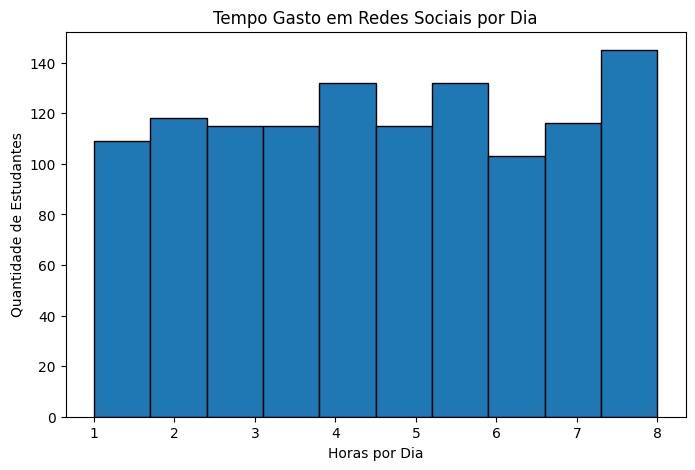

In [ ]:
plt.figure(figsize=(8, 5))
plt.hist(mh["Tempo_gasto_redes"], bins=10,  edgecolor="black")

plt.title("Tempo Gasto em Redes Sociais por Dia")
plt.xlabel("Horas por Dia")
plt.ylabel("Quantidade de Estudantes")

plt.show()

#Nessa célula, construímos um histograma para analisar a distribuição do tempo diário gasto pelos estudantes nas redes sociais.
#Utilizamos a variável Tempo_gasto_redes para representar a quantidade de horas dedicadas a essas plataformas, dividimos os dados em 10 intervalos (bins)
#para facilitar a visualização da frequência de ocorrência dos valores e usamos o edgecolor para limitar as barras e ficar visualmente melhor.
#Essa representação gráfica permite identificar padrões de comportamento, como as faixas de tempo mais comuns entre os participantes,
#além de possibilitar a observação da dispersão e concentração dos dados.

#Testando hipóteses

##Quanto mais tempo gasto em redes, menos sono?

In [ ]:

mh[["Tempo_gasto_redes", "Horas_dormidas"]].corr()

#Nessa célula, analisamos a correlação entre o tempo gasto nas redes sociais e a quantidade de horas dormidas
#pelos estudantes. Para isso, selecionamos essas duas variáveis e utilizamos o método corr(), responsável por calcular o coeficiente de correlação de Pearson.
#O objetivo dessa análise foi investigar se existe alguma relação linear
#entre o uso das redes sociais e a duração do sono dos participantes, verificando, por exemplo, se maiores tempos de uso estão associados a menos horas de descanso.

,Tempo_gasto_redes,Horas_dormidas
Tempo_gasto_redes,1.000000,-0.009472
Horas_dormidas,-0.009472,1.000000


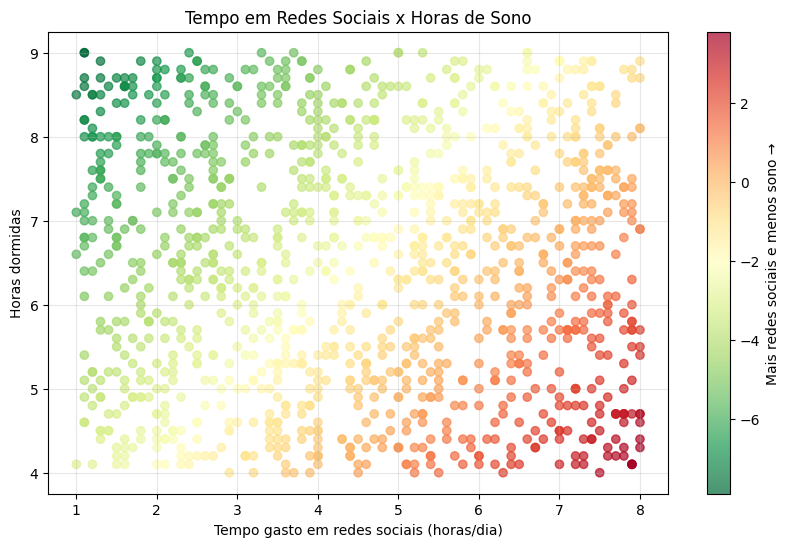

In [ ]:
# Score para colorir os pontos
score = mh["Tempo_gasto_redes"] - mh["Horas_dormidas"]

plt.figure(figsize=(10, 6))

scatter = plt.scatter(
    mh["Tempo_gasto_redes"],
    mh["Horas_dormidas"],
    c=score,
    cmap="RdYlGn_r",  # Verde -> Amarelo -> Vermelho
    alpha=0.7
)

plt.colorbar(
    scatter,
    label="Mais redes sociais e menos sono →"
)

plt.title("Tempo em Redes Sociais x Horas de Sono")
plt.xlabel("Tempo gasto em redes sociais (horas/dia)")
plt.ylabel("Horas dormidas")
plt.grid(alpha=0.3)

plt.show()

#Nessa célula, construímos um gráfico de dispersão (scatter plot) para investigar a relação entre o tempo gasto nas redes sociais e
#a quantidade de horas dormidas pelos estudantes. Cada ponto do gráfico representa um participante da pesquisa,
#sendo que o eixo horizontal corresponde ao tempo diário de uso das redes sociais e o eixo vertical representa as horas de sono.
#Além disso, criamos um indicador denominado score, obtido pela diferença entre o tempo gasto nas redes sociais e as horas dormidas,
#que foi utilizado para colorir os pontos do gráfico. Dessa forma, a visualização permite identificar possíveis padrões,
#como a tendência de estudantes que utilizam mais as redes sociais apresentarem menos horas de sono.

##Quanto maior o nível de dependência, maior a ansiedade?

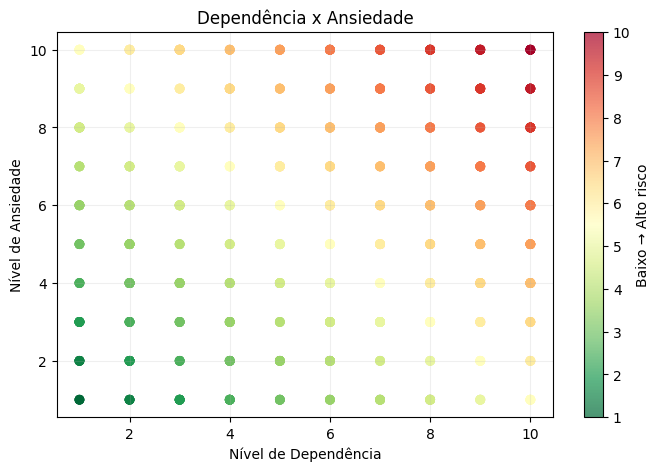

In [16]:
x = mh["Nivel_dependência"]
y = mh["Nivel_ansiedade"]

score = (x + y) / 2

plt.figure(figsize=(8,5))

scatter = plt.scatter(
    x,
    y,
    c=score,
    cmap="RdYlGn_r",
    alpha=0.7
)

plt.colorbar(scatter, label="Baixo → Alto risco")

plt.title("Dependência x Ansiedade")
plt.xlabel("Nível de Dependência")
plt.ylabel("Nível de Ansiedade")

plt.grid(alpha=0.2)

plt.show()



#Nesta célula, utilizamos um gráfico de dispersão (scatter plot) para analisar a relação entre
#o nível de dependência das redes sociais e o nível de ansiedade dos participantes.
#Cada ponto representa um indivíduo da amostra, permitindo visualizar como essas duas variáveis
#se comportam em conjunto.
#Além disso, foi calculado um índice de risco médio a partir dos níveis de dependência e ansiedade,
#utilizado para colorir os pontos no gráfico. A escala de cores varia de baixo para alto risco,
#facilitando a identificação de participantes com maiores níveis simultâneos dessas características.
#Por meio dessa análise, é possível observar possíveis correlações entre dependência e ansiedade,
#bem como identificar padrões, concentrações e casos de maior vulnerabilidade dentro do conjunto de dados.

##Quem dorme mais tem menos ansiedade?

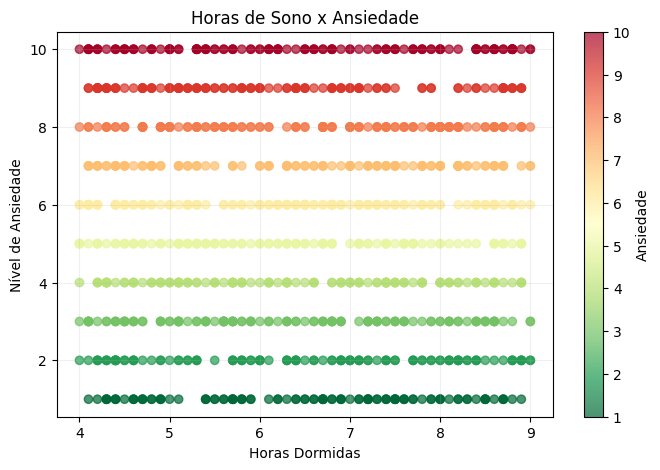

In [17]:
x = mh["Horas_dormidas"]
y = mh["Nivel_ansiedade"]

score = y

plt.figure(figsize=(8,5))

scatter = plt.scatter(
    x,
    y,
    c=score,
    cmap="RdYlGn_r",
    alpha=0.7
)

plt.colorbar(scatter, label="Ansiedade")

plt.title("Horas de Sono x Ansiedade")
plt.xlabel("Horas Dormidas")
plt.ylabel("Nível de Ansiedade")

plt.grid(alpha=0.2)

plt.show()


#Nesta célula, utilizamos um gráfico de dispersão (scatter plot) para analisar a relação entre
#a quantidade de horas dormidas e o nível de ansiedade dos participantes.
#Cada ponto representa um indivíduo da amostra, permitindo observar como os níveis de ansiedade
#se distribuem em função do tempo de sono.
#A coloração dos pontos foi definida pelo próprio nível de ansiedade, utilizando uma escala de cores
#que varia de menor para maior intensidade, facilitando a identificação de participantes com níveis
#mais elevados dessa condição.
#Por meio dessa visualização, é possível investigar a existência de padrões ou tendências entre
#as horas de sono e a ansiedade, verificando, por exemplo, se menores períodos de descanso estão
#associados a níveis mais altos de ansiedade entre os adolescentes analisados.

##Nível de vício varia por gênero?

In [ ]:

mh.groupby("Gênero")["Nivel_dependência"].mean()

#Nessa célula, analisamos se o nível médio de dependência das redes sociais varia entre os gêneros.
#Para isso, utilizamos o método groupby() para agrupar os participantes de acordo com a variável Gênero e, em seguida, aplicamos a função mean()
#sobre a variável Nivel_dependência. Essa análise permitiu comparar a média dos níveis de dependência entre os grupos,
#possibilitando identificar se existe alguma diferença significativa no comportamento relacionado ao uso das redes sociais entre estudantes do sexo masculino e feminino.

,Nivel_dependência
Gênero,
Feminino,5.48547
Masculino,5.64065


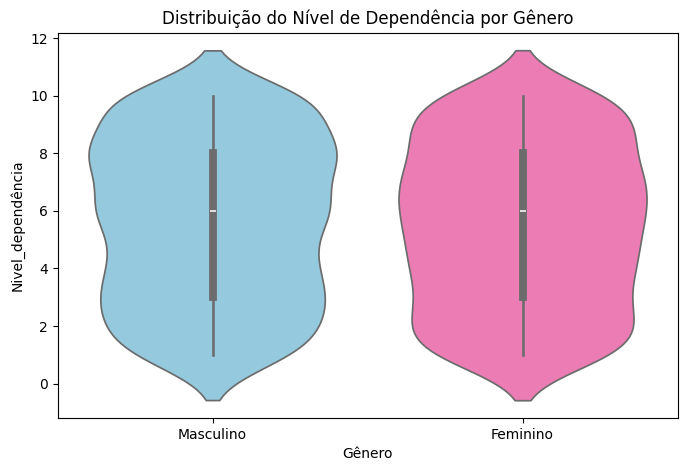

In [ ]:
plt.figure(figsize=(8,5))

sns.violinplot(
    data=mh,
    x="Gênero",
    y="Nivel_dependência",
    hue="Gênero",
    palette={
        "Masculino": "#87CEEB",
        "Feminino": "#FF69B4"
    },
    legend=False
)

plt.title("Distribuição do Nível de Dependência por Gênero")
plt.show()

#Nessa célula, utilizamos um gráfico do tipo violin plot para analisar a distribuição dos níveis de dependência em relação às redes sociais
#de acordo com o gênero dos participantes. Diferentemente de um gráfico de barras, essa visualização permite observar não apenas
#a tendência central dos dados, mas também a dispersão e a concentração dos valores em cada grupo.
#As cores foram definidas para facilitar a distinção entre os gêneros, tornando a interpretação dos resultados mais intuitiva.
#Por meio dessa análise, foi possível investigar se existem diferenças no comportamento relacionado à dependência das redes sociais
#entre estudantes do sexo masculino e feminino.

##Estresse varia com interação Social?

In [ ]:

mh.groupby("Nível_interação_social")["Nivel_estress"].mean().round(2)

#Nessa célula, investigamos como os níveis de estresse dos estudantes variam de acordo com o grau de interação social relatado pelos participantes.
#Para isso, utilizamos o método groupby() para agrupar os dados com base na variável Nível_interação_social e, em seguida, calculamos a média
#da variável Nivel_estress por meio da função mean(). Por fim, aplicamos o método round(2) para arredondar os resultados para duas casas decimais,
#facilitando a leitura e a interpretação dos valores.
#Essa análise permite identificar se estudantes com diferentes níveis de interação social apresentam diferenças nos níveis médios de estresse.

,Nivel_estress
Nível_interação_social,
Alto,5.51
Baixo,5.35
Médio,5.48


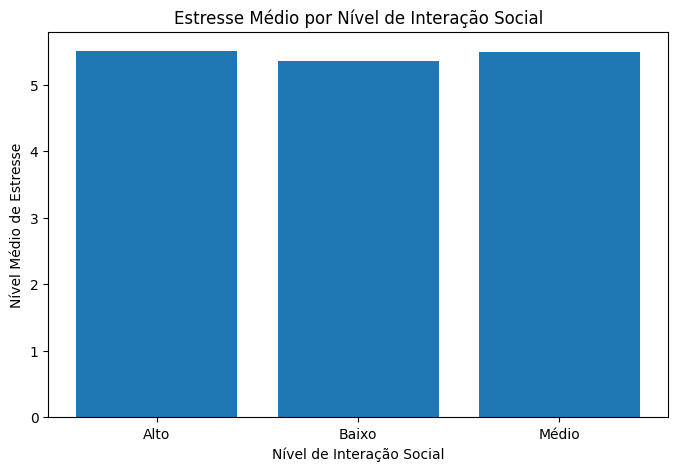

In [ ]:
estresse = mh.groupby("Nível_interação_social")["Nivel_estress"].mean()

plt.figure(figsize=(8, 5))
plt.bar(estresse.index, estresse.values)

plt.title("Estresse Médio por Nível de Interação Social")
plt.xlabel("Nível de Interação Social")
plt.ylabel("Nível Médio de Estresse")

plt.show()

#Nessa célula, construímos um gráfico de barras para visualizar como o nível médio de estresse varia de acordo com o nível de interação social dos estudantes.
#Inicialmente, agrupamos os participantes com base na variável Nível_interação_social e calculamos a média dos valores da variável Nivel_estress para cada grupo.
#Em seguida, utilizamos essas informações para gerar uma representação gráfica que facilita a comparação entre os diferentes níveis de interação social.
#Essa análise permite investigar se estudantes com menor ou maior interação social apresentam diferenças nos níveis médios de estresse, contribuindo
#para a compreensão dos fatores associados ao bem-estar emocional dos participantes.

##Mais atividade fisica = melhor nota?

In [7]:

correlacao = mh["Atividade_fisica"].corr(mh["Performance_academica"])

print(f"Correlação: {correlacao:.3f}")

#Correlação positiva → mais atividade física tende a estar associada a melhores notas.
#Correlação próxima de zero → pouca ou nenhuma relação.
#Correlação negativa → mais atividade física tende a estar associada a notas menores.

#Nessa célula, investigamos a existência de uma possível relação entre a prática de atividade física e o desempenho acadêmico dos estudantes.
#Para isso, calculamos o coeficiente de correlação de Pearson entre as variáveis Atividade_fisica e Performance_academica, utilizando o método corr().
#Essa análise teve como objetivo verificar se estudantes que realizam mais atividades físicas tendem a apresentar melhor desempenho acadêmico.




Correlação: 0.023


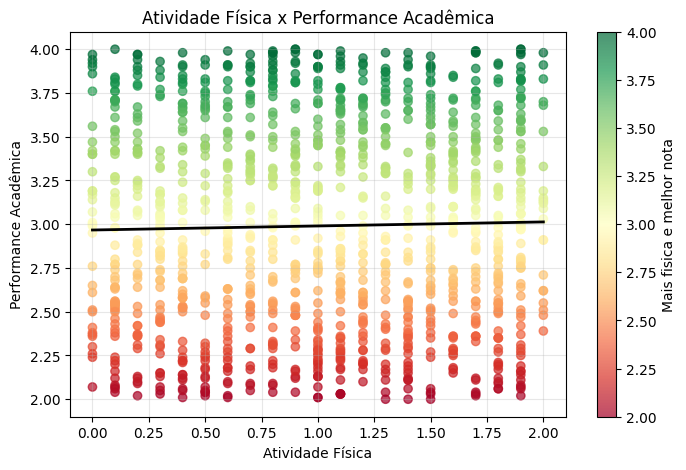

In [8]:
x = mh["Atividade_fisica"]
y = mh["Performance_academica"]

plt.figure(figsize=(8, 5))

scatter = plt.scatter(
    x,
    y,
    c=y,               # cor baseada na performance
    cmap="RdYlGn",     # Vermelho → Amarelo → Verde
    alpha=0.7
)

# Linha de tendência
coef = np.polyfit(x, y, 1)
linha = np.poly1d(coef)

x_ord = np.sort(x)
plt.plot(x_ord, linha(x_ord), color="black", linewidth=2)

# Barra de cores
cbar = plt.colorbar(scatter)
cbar.set_label("Mais fisica e melhor nota")

plt.title("Atividade Física x Performance Acadêmica")
plt.xlabel("Atividade Física")
plt.ylabel("Performance Acadêmica")
plt.grid(alpha=0.3)

plt.show()

#Nessa célula, construímos um gráfico de dispersão para investigar visualmente a relação entre a prática de atividade física e a
#performance acadêmica dos estudantes. Cada ponto do gráfico representa um participante da pesquisa, sendo posicionado de acordo com seu nível de atividade física
#e seu desempenho acadêmico. Além disso, aplicamos uma escala de cores baseada na variável Performance_academica, permitindo identificar visualmente estudantes
#com melhores ou piores resultados. Para complementar a análise, adicionamos uma linha de tendência linear, com o objetivo de evidenciar a direção geral
#da relação entre as variáveis. Essa abordagem possibilita avaliar se maiores níveis de atividade física estão associados a um melhor desempenho acadêmico.

##Como se distribuem os níveis de ansiedade e estresse?

In [9]:

mh[["Nivel_ansiedade", "Nivel_estress"]].describe()

#Nessa célula, realizamos uma análise descritiva das variáveis Nivel_ansiedade e Nivel_estress por meio do método describe().
#O objetivo foi obter um resumo estatístico dessas duas dimensões relacionadas à saúde mental dos estudantes,
#permitindo compreender como seus valores estão distribuídos na amostra.
#Essa etapa fornece informações importantes sobre a tendência central e a dispersão dos dados, contribuindo para uma interpretação
#mais detalhada dos níveis de ansiedade e estresse apresentados pelos participantes.

,Nivel_ansiedade,Nivel_estress
count,1200.000000,1200.000000
mean,5.636667,5.445833
std,2.859453,2.903290
min,1.000000,1.000000
25%,3.000000,3.000000
50%,6.000000,5.000000
75%,8.000000,8.000000
max,10.000000,10.000000


##Quanto mais ansiedade, mais estresse?

In [10]:

mh["Nivel_ansiedade"].corr(mh["Nivel_estress"])

#Nessa célula, analisamos a relação entre os níveis de ansiedade e estresse dos estudantes por meio do cálculo do coeficiente de correlação de Pearson.
#Para isso, utilizamos o método corr() para verificar a intensidade e a direção da associação linear entre as variáveis Nivel_ansiedade e Nivel_estress.
#Além disso, estabelecemos uma tabela de classificação para interpretar a força da correlação obtida.
#Essa análise teve como objetivo investigar se estudantes com níveis mais elevados de ansiedade também tendem a apresentar maiores níveis de estresse.


#Correlação       Significado

#0,00 a 0,19     Muito fraca
#0,20 a 0,39       Fraca
#0,40 a 0,59      Moderada
#0,60 a 0,79       Forte
#0,80 a 1,00    Muito forte

np.float64(0.01581125345622227)

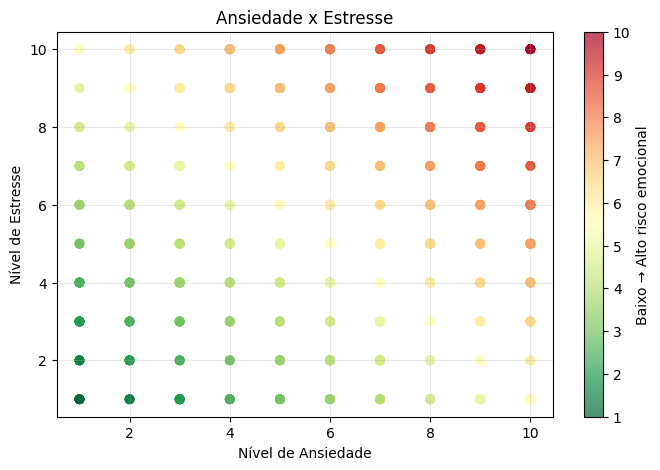

In [11]:
x = mh["Nivel_ansiedade"]
y = mh["Nivel_estress"]

score = (x + y) / 2

plt.figure(figsize=(8, 5))

scatter = plt.scatter(
    x,
    y,
    c=score,
    cmap="RdYlGn_r",
    alpha=0.7
)

plt.colorbar(scatter, label="Baixo → Alto risco emocional")

plt.title("Ansiedade x Estresse")
plt.xlabel("Nível de Ansiedade")
plt.ylabel("Nível de Estresse")
plt.grid(alpha=0.3)

plt.show()

#Nessa célula, analisamos a relação entre os níveis de ansiedade e estresse dos estudantes por meio do cálculo do coeficiente de correlação de Pearson.
#Para isso, utilizamos o método corr() para verificar a intensidade e a direção da associação linear entre as variáveis Nivel_ansiedade e Nivel_estress.
#Além disso, estabelecemos uma tabela de classificação para auxiliar na interpretação da força da correlação obtida.
#Essa análise teve como objetivo investigar se estudantes com níveis mais elevados de ansiedade também tendem a apresentar maiores níveis de estresse,
#contribuindo para a compreensão da interação entre esses dois importantes indicadores de saúde mental.

##Depressão, tem vinculo com o consumo de mais tela antes de dormir?

In [12]:

mh.groupby("Depressão")["Tempo_tela_antes_dormir"].mean().round(2)

#Nessa célula, investigamos se existe alguma associação entre os níveis de depressão dos estudantes e o tempo de exposição às telas antes de dormir.
#Para isso, utilizamos o método groupby() para agrupar os participantes de acordo com a variável Depressão e, em seguida, calculamos
#a média do tempo de tela antes de dormir para cada grupo. Por fim, aplicamos o método round(2)
#para arredondar os resultados para duas casas decimais, facilitando a interpretação dos dados. Essa análise teve como objetivo
#verificar se estudantes com diferentes níveis de depressão apresentam padrões distintos de uso de dispositivos eletrônicos no período que antecede o sono.

,Tempo_tela_antes_dormir
Depressão,
0,1.74
1,1.67


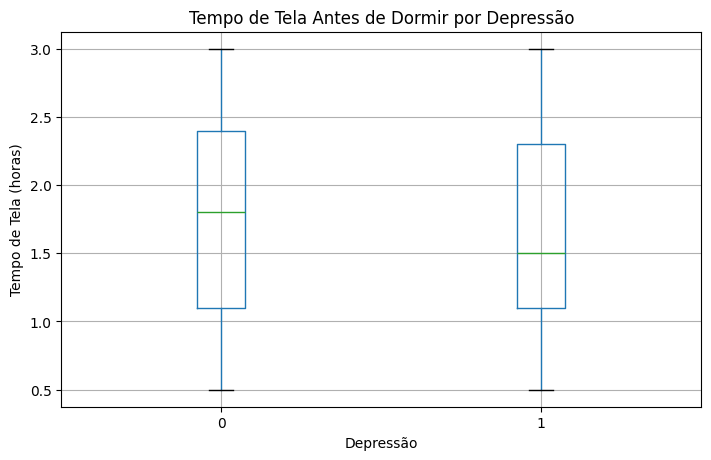

In [13]:
mh.boxplot(
    column="Tempo_tela_antes_dormir",
    by="Depressão",
    figsize=(8, 5)
)

plt.title("Tempo de Tela Antes de Dormir por Depressão")
plt.suptitle("")
plt.xlabel("Depressão")
plt.ylabel("Tempo de Tela (horas)")

plt.show()

#Nessa célula, utilizamos um gráfico do tipo boxplot para analisar a distribuição do tempo de tela antes de dormir em função dos
#diferentes níveis de depressão dos estudantes. Essa visualização permite comparar não apenas os valores médios entre os grupos,
#mas também aspectos importantes da distribuição dos dados, como a mediana, a dispersão e a presença de possíveis valores atípicos (outliers).
#Dessa forma, foi possível investigar se estudantes com diferentes níveis de depressão apresentam padrões distintos de uso de
#dispositivos eletrônicos no período que antecede o sono.

##Qual plataforma está associada ao maior nível médio de dependência?

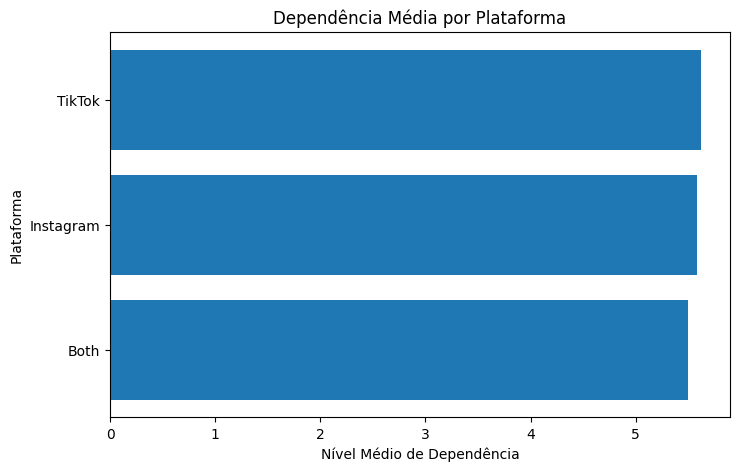

In [18]:
dependencia = (
    mh.groupby("Plataforma_usada")["Nivel_dependência"]
    .mean()
    .sort_values()
)

plt.figure(figsize=(8,5))

plt.barh(
    dependencia.index,
    dependencia.values
)

plt.title("Dependência Média por Plataforma")
plt.xlabel("Nível Médio de Dependência")
plt.ylabel("Plataforma")

plt.show()


#Nesta célula, utilizamos um gráfico de barras horizontais para comparar o nível médio de
#dependência das redes sociais entre as diferentes plataformas utilizadas pelos participantes.
#Inicialmente, os dados foram agrupados por plataforma, calculando-se a média do nível de
#dependência para cada uma delas. Em seguida, os valores foram ordenados de forma crescente,
#facilitando a visualização e comparação dos resultados.
#Cada barra representa uma plataforma específica, enquanto seu comprimento indica o nível
#médio de dependência associado aos usuários daquela plataforma.
#Por meio dessa análise, é possível identificar quais plataformas apresentam maiores ou menores
#índices médios de dependência, contribuindo para a compreensão do impacto potencial de cada
#rede social no comportamento dos adolescentes estudados.

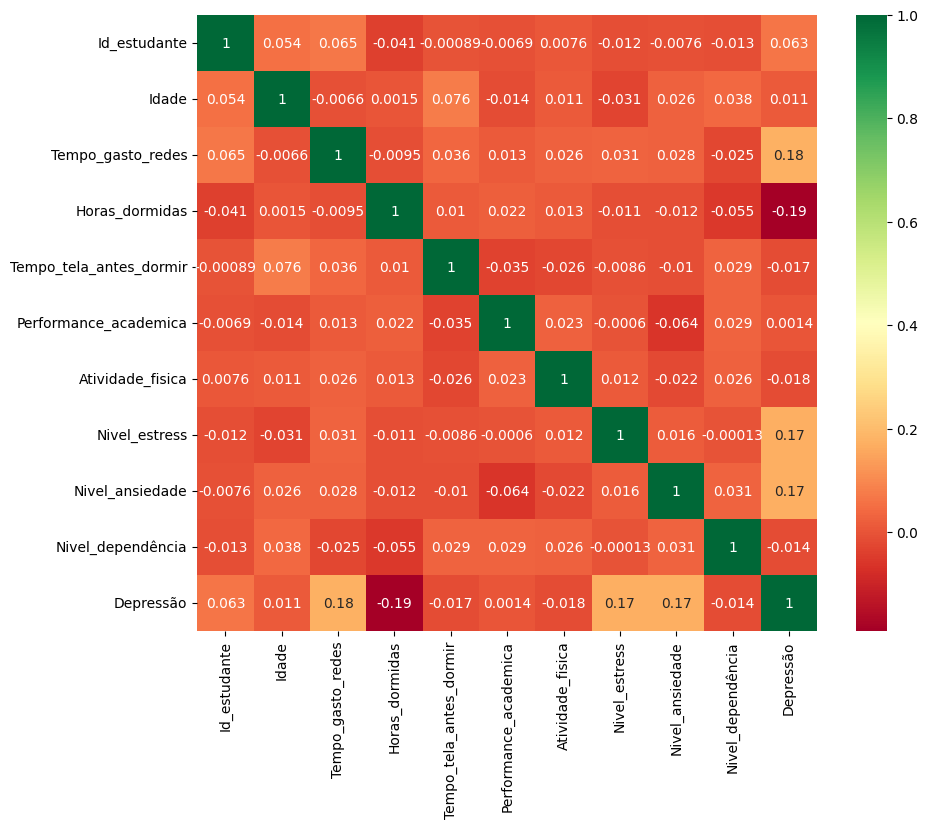

In [14]:
plt.figure(figsize=(10,8))
sns.heatmap(
    mh.corr(numeric_only=True),
    annot=True,
    cmap="RdYlGn"
)
plt.show()

#Nessa célula, construímos um mapa de calor (heatmap) para visualizar as correlações existentes entre todas as variáveis numéricas da base de dados.
#Para isso, utilizamos o método corr() para calcular os coeficientes de correlação de Pearson e, em seguida, representamos esses valores graficamente com o
#auxílio da função heatmap() da biblioteca Seaborn. Essa visualização permite identificar padrões de associação entre as variáveis, destacando tanto correlações
#positivas quanto negativas, além de evidenciar quais relações apresentam maior ou menor intensidade. Dessa forma, o mapa de calor fornece uma visão geral das
#interações presentes no conjunto de dados, auxiliando na identificação de possíveis fatores relacionados à saúde mental e aos hábitos dos estudantes.